# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot configuration
sns.set_theme(rc={'figure.dpi': 300})

# Read dataset

In [2]:
df = pd.read_csv("clean_dataset.csv", parse_dates=[0])
df

,record_date,avg_temp,hi_temp,low_temp,out_hum,dew_pt,wind_speed,wind_direction,wind_run,hi_speed,...,in_hum,in_dew,in_heat,in_emc,in_air_density,et,wind_samp,wind_tx,iss_recept,arc_int
0,2008-01-18 03:45:00,15.0,15.0,14.9,74.0,10.4,0.0,Calm,0.0,0.0,...,43.0,12.9,26.0,8.05,1.1588,0.00,351,1,100.0,15
1,2008-01-18 04:00:00,14.8,15.0,14.7,75.0,10.4,0.0,Calm,0.0,0.0,...,44.0,13.1,25.9,8.16,1.1588,0.03,352,1,100.0,15
2,2008-01-18 04:15:00,14.5,14.7,14.4,76.0,10.3,0.0,Calm,0.0,0.0,...,44.0,13.0,25.8,8.17,1.1597,0.00,351,1,100.0,15
3,2008-01-18 04:30:00,14.3,14.4,14.3,76.0,10.2,0.0,S,0.0,1.6,...,44.0,12.9,25.7,8.17,1.1602,0.00,351,1,100.0,15
4,2008-01-18 04:45:00,14.2,14.3,14.1,76.0,10.0,0.0,Calm,0.0,0.0,...,44.0,12.8,25.6,8.18,1.1609,0.00,351,1,100.0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634330,2026-05-18 18:45:00,15.6,16.7,15.6,18.0,-8.7,1.6,SSW,0.4,6.4,...,28.0,-0.7,16.0,5.96,1.2076,0.00,352,1,100.0,15
634331,2026-05-18 19:00:00,14.8,15.6,14.8,19.0,-8.6,1.6,SW,0.4,4.8,...,28.0,-0.7,15.9,5.96,1.2079,0.05,348,1,100.0,15
634332,2026-05-18 19:15:00,13.9,14.8,13.9,20.0,-8.7,0.0,SW,0.0,1.6,...,27.0,-1.3,15.7,5.85,1.2090,0.00,351,1,100.0,15
634333,2026-05-18 19:30:00,13.1,13.9,13.1,20.0,-9.4,0.0,SW,0.0,1.6,...,27.0,-1.4,15.6,5.85,1.2097,0.00,351,1,100.0,15


# Wind Direction
## Checking values

In [3]:
df["wind_direction"].value_counts()

wind_direction
Calm    220162
ESE      58333
SE       57295
NE       53576
ENE      43851
NNE      29515
E        25604
N        22127
W        20788
NNW      17453
SSW      15975
SSE      15545
S        15112
SW       10813
NW        9969
WSW       9337
WNW       8880
Name: count, dtype: int64

## Transforming using sine and cosine functions
Note that cyclic variables have a repeating pattern over a defined interval. In ML, capturing their nature could be challenging to do.

Therefore, an approach to solve this problem is using sine and cosine functions to transform the cyclical variable into two new components that preserve cyclicity.

In [4]:
dir_trig = {
    "N":    [np.sin(np.deg2rad(0)), np.cos(np.deg2rad(0))],
    "NNE":  [np.sin(np.deg2rad(22.5)), np.cos(np.deg2rad(22.5))],
    "NE":   [np.sin(np.deg2rad(45)), np.cos(np.deg2rad(45))],
    "ENE":  [np.sin(np.deg2rad(67.5)), np.cos(np.deg2rad(67.5))],
    "E":    [np.sin(np.deg2rad(90)), np.cos(np.deg2rad(90))],
    "ESE":  [np.sin(np.deg2rad(112.5)), np.cos(np.deg2rad(112.5))],
    "SE":   [np.sin(np.deg2rad(135)), np.cos(np.deg2rad(135))],
    "SSE":  [np.sin(np.deg2rad(157.5)), np.cos(np.deg2rad(157.5))],
    "S":    [np.sin(np.deg2rad(180)), np.cos(np.deg2rad(180))],
    "SSW":  [np.sin(np.deg2rad(202.5)), np.cos(np.deg2rad(202.5))],
    "SW":   [np.sin(np.deg2rad(225)), np.cos(np.deg2rad(225))],
    "WSW":  [np.sin(np.deg2rad(247.5)), np.cos(np.deg2rad(247.5))],
    "W":    [np.sin(np.deg2rad(270)), np.cos(np.deg2rad(270))],
    "WNW":  [np.sin(np.deg2rad(292.5)), np.cos(np.deg2rad(292.5))],
    "NW":   [np.sin(np.deg2rad(315)), np.cos(np.deg2rad(315))],
    "NNW":  [np.sin(np.deg2rad(337.5)), np.cos(np.deg2rad(337.5))],
    "Calm": [0,0]
}
df["wind_direction_x"] = df["wind_direction"].map(lambda x: dir_trig[x][0])
df["wind_direction_y"] = df["wind_direction"].map(lambda x: dir_trig[x][1])
df["wind_hi_dir_x"] = df["hi_dir"].map(lambda x: dir_trig[x][0])
df["wind_hi_dir_y"] = df["hi_dir"].map(lambda x: dir_trig[x][1])
df.drop(columns=["wind_direction","hi_dir"], inplace=True)
df

,record_date,avg_temp,hi_temp,low_temp,out_hum,dew_pt,wind_speed,wind_run,hi_speed,wind_chill,...,in_air_density,et,wind_samp,wind_tx,iss_recept,arc_int,wind_direction_x,wind_direction_y,wind_hi_dir_x,wind_hi_dir_y
0,2008-01-18 03:45:00,15.0,15.0,14.9,74.0,10.4,0.0,0.0,0.0,15.0,...,1.1588,0.00,351,1,100.0,15,0.000000e+00,0.000000,0.000000e+00,0.000000
1,2008-01-18 04:00:00,14.8,15.0,14.7,75.0,10.4,0.0,0.0,0.0,14.8,...,1.1588,0.03,352,1,100.0,15,0.000000e+00,0.000000,0.000000e+00,0.000000
2,2008-01-18 04:15:00,14.5,14.7,14.4,76.0,10.3,0.0,0.0,0.0,14.5,...,1.1597,0.00,351,1,100.0,15,0.000000e+00,0.000000,0.000000e+00,0.000000
3,2008-01-18 04:30:00,14.3,14.4,14.3,76.0,10.2,0.0,0.0,1.6,14.3,...,1.1602,0.00,351,1,100.0,15,1.224647e-16,-1.000000,1.224647e-16,-1.000000
4,2008-01-18 04:45:00,14.2,14.3,14.1,76.0,10.0,0.0,0.0,0.0,14.2,...,1.1609,0.00,351,1,100.0,15,0.000000e+00,0.000000,0.000000e+00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634330,2026-05-18 18:45:00,15.6,16.7,15.6,18.0,-8.7,1.6,0.4,6.4,15.6,...,1.2076,0.00,352,1,100.0,15,-3.826834e-01,-0.923880,-7.071068e-01,-0.707107
634331,2026-05-18 19:00:00,14.8,15.6,14.8,19.0,-8.6,1.6,0.4,4.8,14.8,...,1.2079,0.05,348,1,100.0,15,-7.071068e-01,-0.707107,-7.071068e-01,-0.707107
634332,2026-05-18 19:15:00,13.9,14.8,13.9,20.0,-8.7,0.0,0.0,1.6,13.9,...,1.2090,0.00,351,1,100.0,15,-7.071068e-01,-0.707107,-7.071068e-01,-0.707107
634333,2026-05-18 19:30:00,13.1,13.9,13.1,20.0,-9.4,0.0,0.0,1.6,13.1,...,1.2097,0.00,351,1,100.0,15,-7.071068e-01,-0.707107,-7.071068e-01,-0.707107


# Record Date
## Transforming using sine and cosine functions

In [5]:
record_date_month = df["record_date"].dt.month
record_date_day = df["record_date"].dt.dayofyear
record_date_hour = df['record_date'].dt.hour
record_date_minutes = df['record_date'].dt.minute/60
time_of_day = record_date_hour+record_date_minutes

# Month Cycle
df['month_sin'] = np.sin(2 * np.pi * ((record_date_month-1) / 12))
df['month_cos'] = np.cos(2 * np.pi * ((record_date_month-1) / 12))

# Day Cycle
df['day_sin'] = np.sin(2 * np.pi * ((record_date_day-1) / 365.25))
df['day_cos'] = np.cos(2 * np.pi * ((record_date_day-1) / 365.25))

# Hour/Minute Cycle
df['time_sin'] = np.sin(2 * np.pi * (time_of_day / 24))
df['time_cos'] = np.cos(2 * np.pi * (time_of_day / 24))
df

,record_date,avg_temp,hi_temp,low_temp,out_hum,dew_pt,wind_speed,wind_run,hi_speed,wind_chill,...,wind_direction_x,wind_direction_y,wind_hi_dir_x,wind_hi_dir_y,month_sin,month_cos,day_sin,day_cos,time_sin,time_cos
0,2008-01-18 03:45:00,15.0,15.0,14.9,74.0,10.4,0.0,0.0,0.0,15.0,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,1.0,0.288291,0.957543,0.831470,0.555570
1,2008-01-18 04:00:00,14.8,15.0,14.7,75.0,10.4,0.0,0.0,0.0,14.8,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,1.0,0.288291,0.957543,0.866025,0.500000
2,2008-01-18 04:15:00,14.5,14.7,14.4,76.0,10.3,0.0,0.0,0.0,14.5,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,1.0,0.288291,0.957543,0.896873,0.442289
3,2008-01-18 04:30:00,14.3,14.4,14.3,76.0,10.2,0.0,0.0,1.6,14.3,...,1.224647e-16,-1.000000,1.224647e-16,-1.000000,0.000000,1.0,0.288291,0.957543,0.923880,0.382683
4,2008-01-18 04:45:00,14.2,14.3,14.1,76.0,10.0,0.0,0.0,0.0,14.2,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,1.0,0.288291,0.957543,0.946930,0.321439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634330,2026-05-18 18:45:00,15.6,16.7,15.6,18.0,-8.7,1.6,0.4,6.4,15.6,...,-3.826834e-01,-0.923880,-7.071068e-01,-0.707107,0.866025,-0.5,0.706727,-0.707487,-0.980785,0.195090
634331,2026-05-18 19:00:00,14.8,15.6,14.8,19.0,-8.6,1.6,0.4,4.8,14.8,...,-7.071068e-01,-0.707107,-7.071068e-01,-0.707107,0.866025,-0.5,0.706727,-0.707487,-0.965926,0.258819
634332,2026-05-18 19:15:00,13.9,14.8,13.9,20.0,-8.7,0.0,0.0,1.6,13.9,...,-7.071068e-01,-0.707107,-7.071068e-01,-0.707107,0.866025,-0.5,0.706727,-0.707487,-0.946930,0.321439
634333,2026-05-18 19:30:00,13.1,13.9,13.1,20.0,-9.4,0.0,0.0,1.6,13.1,...,-7.071068e-01,-0.707107,-7.071068e-01,-0.707107,0.866025,-0.5,0.706727,-0.707487,-0.923880,0.382683


# Dropping columns

In [6]:
df.drop(columns=["arc_int","wind_tx","wind_samp", "iss_recept","wind_chill","heat_index","thw_index","heat_dd", "cool_dd","in_temp", "in_hum", "in_dew", "in_heat", "in_emc", "in_air_density","hi_temp", "low_temp","wind_run", "solar_energy"], inplace=True)

# Using past observations (lag)

In [7]:
original_size_df = len(df.columns)
for i in range(0,original_size_df):
    df[f"{df.columns[i]}_lag1"] = df[f"{df.columns[i]}"].shift(1)
df.dropna(inplace=True)
display(df)

,record_date,avg_temp,out_hum,dew_pt,wind_speed,hi_speed,bar,rain,rain_rate,solar_rad,...,wind_direction_x_lag1,wind_direction_y_lag1,wind_hi_dir_x_lag1,wind_hi_dir_y_lag1,month_sin_lag1,month_cos_lag1,day_sin_lag1,day_cos_lag1,time_sin_lag1,time_cos_lag1
1,2008-01-18 04:00:00,14.8,75.0,10.4,0.0,0.0,1010.8,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,1.0,0.288291,0.957543,0.831470,0.555570
2,2008-01-18 04:15:00,14.5,76.0,10.3,0.0,0.0,1010.8,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,1.0,0.288291,0.957543,0.866025,0.500000
3,2008-01-18 04:30:00,14.3,76.0,10.2,0.0,1.6,1010.8,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,1.0,0.288291,0.957543,0.896873,0.442289
4,2008-01-18 04:45:00,14.2,76.0,10.0,0.0,0.0,1010.9,0.0,0.0,0.0,...,1.224647e-16,-1.000000,1.224647e-16,-1.000000,0.000000,1.0,0.288291,0.957543,0.923880,0.382683
5,2008-01-18 05:00:00,13.9,77.0,10.0,0.0,0.0,1010.8,0.0,0.0,0.0,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,1.0,0.288291,0.957543,0.946930,0.321439
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634330,2026-05-18 18:45:00,15.6,18.0,-8.7,1.6,6.4,1015.1,0.0,0.0,0.0,...,-3.826834e-01,-0.923880,-3.826834e-01,-0.923880,0.866025,-0.5,0.706727,-0.707487,-0.991445,0.130526
634331,2026-05-18 19:00:00,14.8,19.0,-8.6,1.6,4.8,1015.2,0.0,0.0,0.0,...,-3.826834e-01,-0.923880,-7.071068e-01,-0.707107,0.866025,-0.5,0.706727,-0.707487,-0.980785,0.195090
634332,2026-05-18 19:15:00,13.9,20.0,-8.7,0.0,1.6,1015.3,0.0,0.0,0.0,...,-7.071068e-01,-0.707107,-7.071068e-01,-0.707107,0.866025,-0.5,0.706727,-0.707487,-0.965926,0.258819
634333,2026-05-18 19:30:00,13.1,20.0,-9.4,0.0,1.6,1015.4,0.0,0.0,0.0,...,-7.071068e-01,-0.707107,-7.071068e-01,-0.707107,0.866025,-0.5,0.706727,-0.707487,-0.946930,0.321439


In [8]:
df["avg_temp_rolling_avg"] = df["avg_temp"].rolling(window=4).mean().shift(1)
df.dropna(inplace=True)
df

,record_date,avg_temp,out_hum,dew_pt,wind_speed,hi_speed,bar,rain,rain_rate,solar_rad,...,wind_direction_y_lag1,wind_hi_dir_x_lag1,wind_hi_dir_y_lag1,month_sin_lag1,month_cos_lag1,day_sin_lag1,day_cos_lag1,time_sin_lag1,time_cos_lag1,avg_temp_rolling_avg
5,2008-01-18 05:00:00,13.9,77.0,10.0,0.0,0.0,1010.8,0.0,0.0,0.0,...,0.000000,0.000000e+00,0.000000,0.000000,1.0,0.288291,0.957543,0.946930,0.321439,14.450
6,2008-01-18 05:15:00,13.7,78.0,10.0,0.0,0.0,1010.8,0.0,0.0,0.0,...,0.000000,0.000000e+00,0.000000,0.000000,1.0,0.288291,0.957543,0.965926,0.258819,14.225
7,2008-01-18 05:30:00,13.6,79.0,10.0,0.0,6.4,1010.9,0.0,0.0,0.0,...,0.000000,0.000000e+00,0.000000,0.000000,1.0,0.288291,0.957543,0.980785,0.195090,14.025
8,2008-01-18 05:45:00,13.6,78.0,9.8,0.0,1.6,1011.0,0.0,0.0,0.0,...,-1.000000,1.224647e-16,-1.000000,0.000000,1.0,0.288291,0.957543,0.991445,0.130526,13.850
9,2008-01-18 06:00:00,13.6,78.0,9.8,0.0,0.0,1011.2,0.0,0.0,0.0,...,-1.000000,1.224647e-16,-1.000000,0.000000,1.0,0.288291,0.957543,0.997859,0.065403,13.700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634330,2026-05-18 18:45:00,15.6,18.0,-8.7,1.6,6.4,1015.1,0.0,0.0,0.0,...,-0.923880,-3.826834e-01,-0.923880,0.866025,-0.5,0.706727,-0.707487,-0.991445,0.130526,18.450
634331,2026-05-18 19:00:00,14.8,19.0,-8.6,1.6,4.8,1015.2,0.0,0.0,0.0,...,-0.923880,-7.071068e-01,-0.707107,0.866025,-0.5,0.706727,-0.707487,-0.980785,0.195090,17.250
634332,2026-05-18 19:15:00,13.9,20.0,-8.7,0.0,1.6,1015.3,0.0,0.0,0.0,...,-0.707107,-7.071068e-01,-0.707107,0.866025,-0.5,0.706727,-0.707487,-0.965926,0.258819,16.225
634333,2026-05-18 19:30:00,13.1,20.0,-9.4,0.0,1.6,1015.4,0.0,0.0,0.0,...,-0.707107,-7.071068e-01,-0.707107,0.866025,-0.5,0.706727,-0.707487,-0.946930,0.321439,15.250


# Correlation Matrix
Shows correlation coefficients between the variables of the dataset.

1 = Perfect Correlation

0 = No Correlation

-1 = Perfect Negative Correlation

## Original

<Axes: >

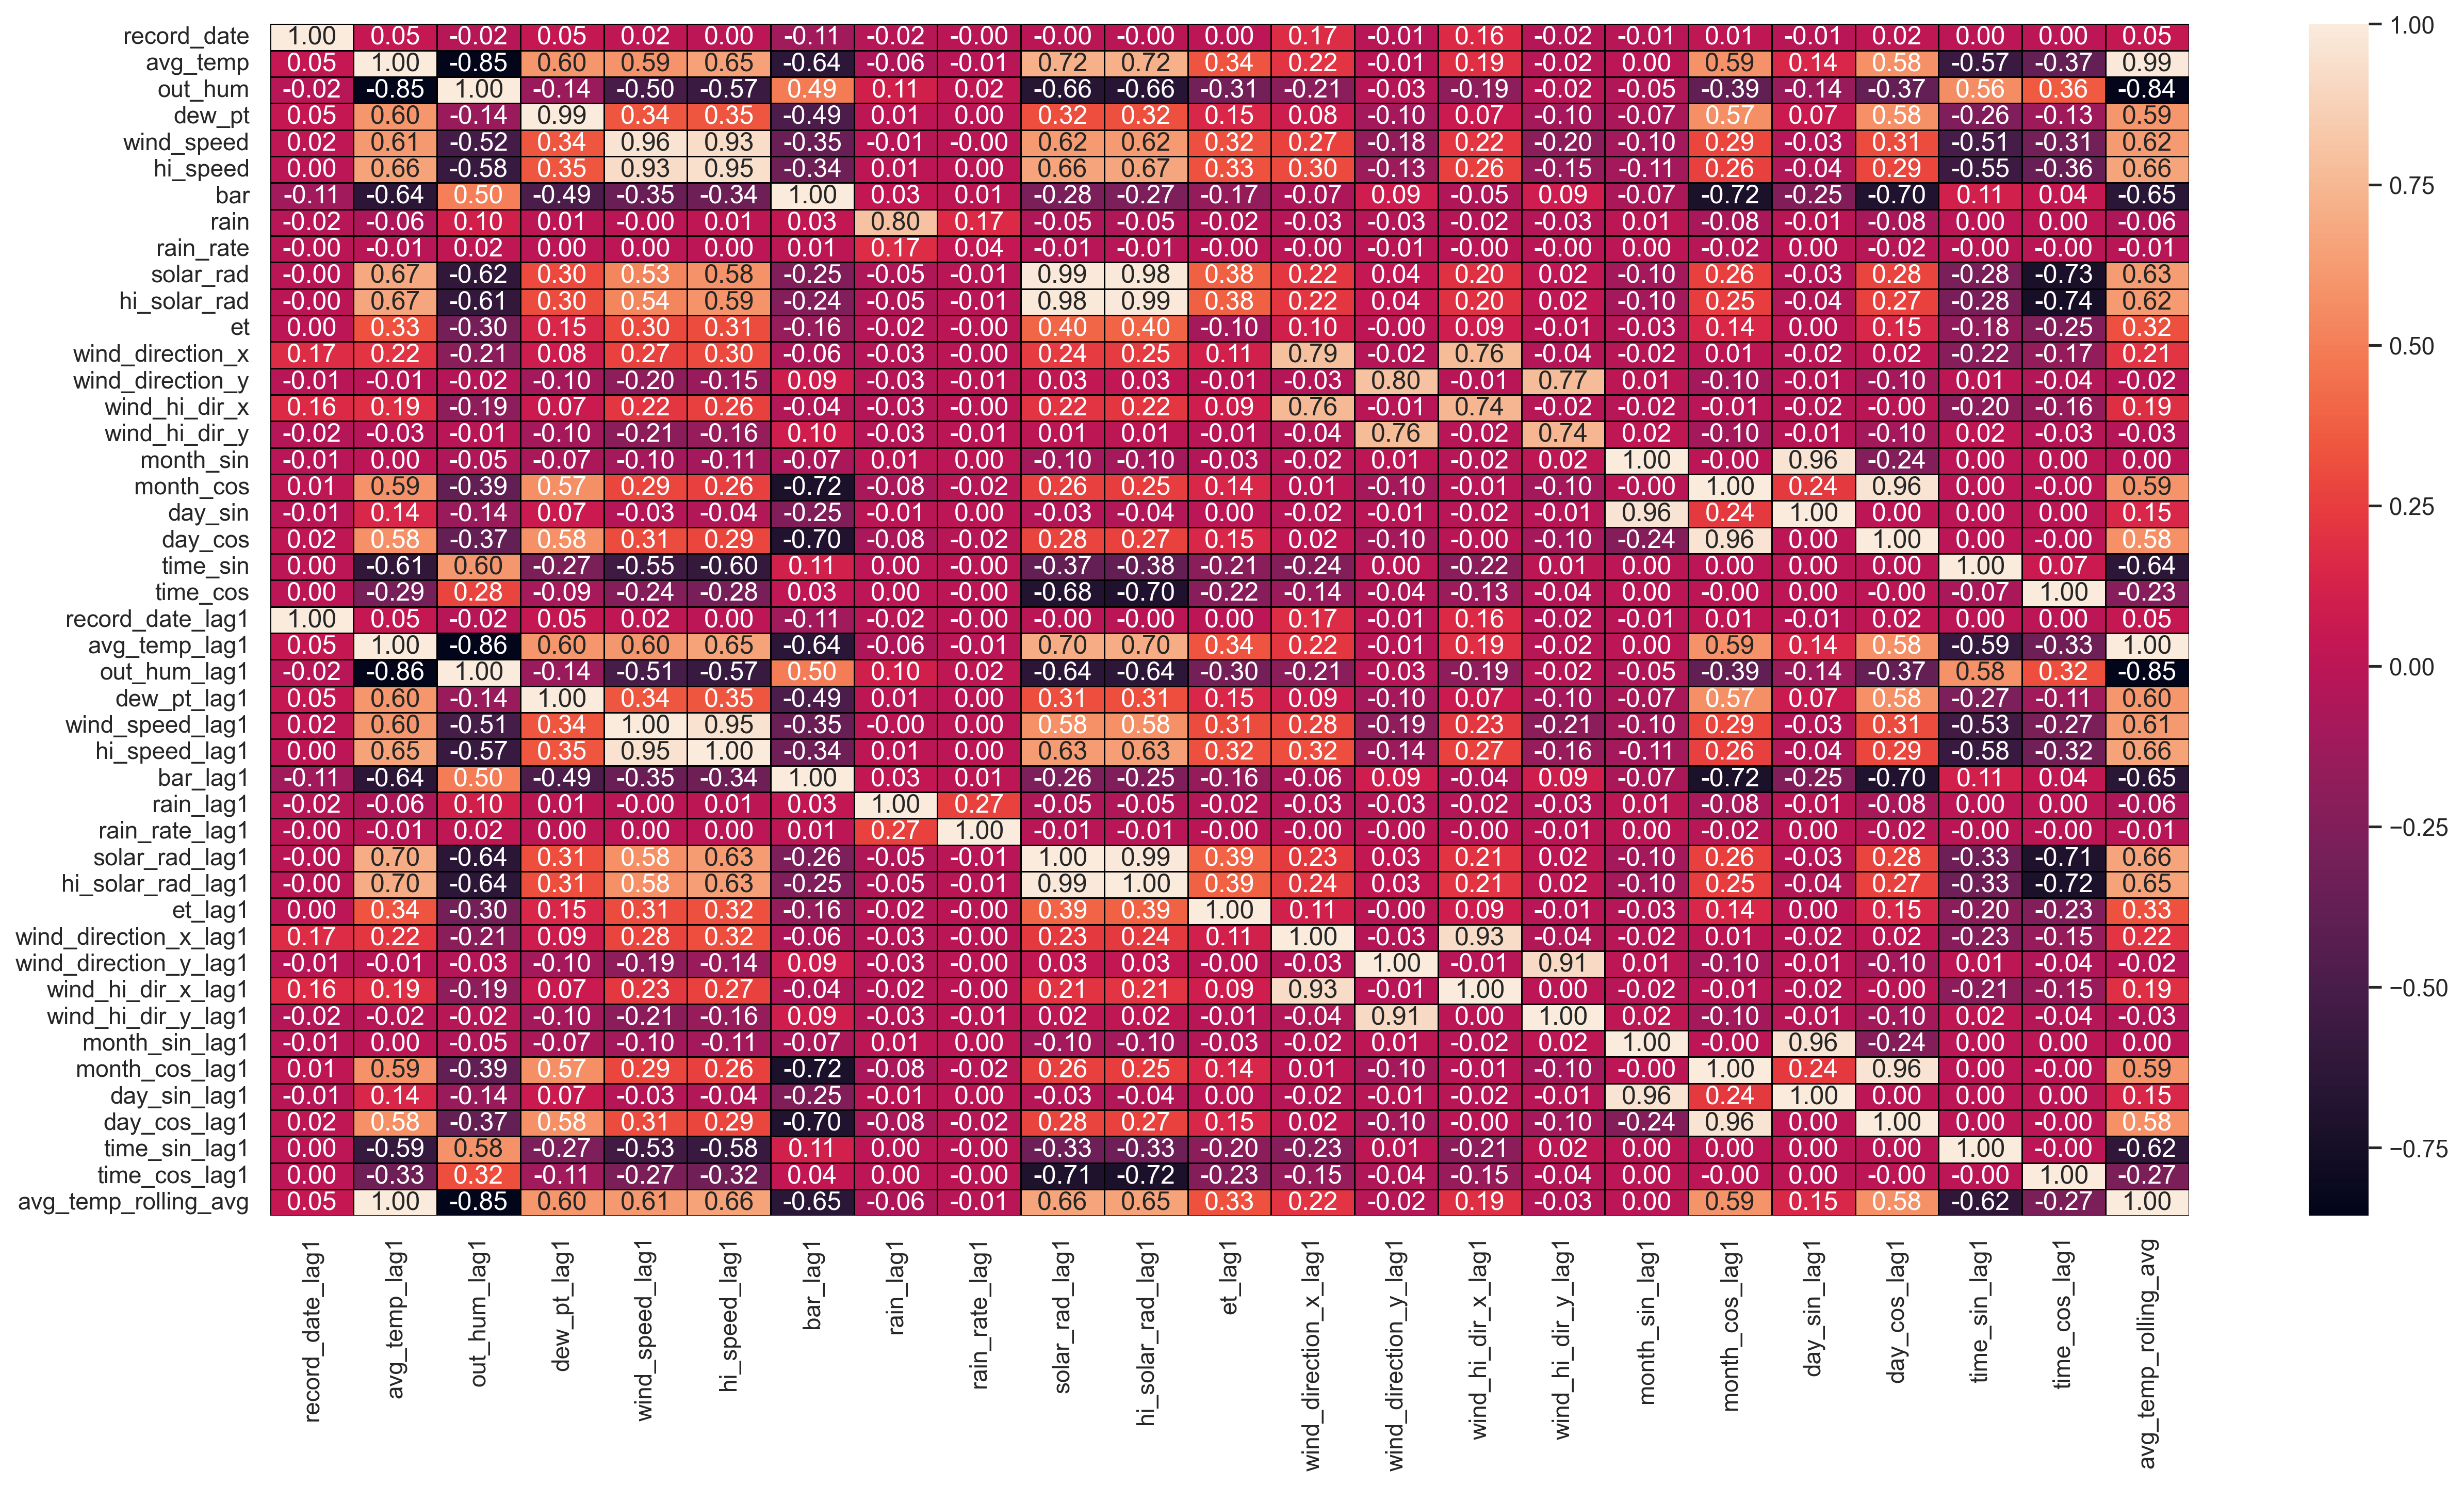

In [9]:
corr_matrix = df.corr()[df.columns[22:]]

plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidth=".25", linecolor="black")

## Removing under performing correlations

<Axes: >

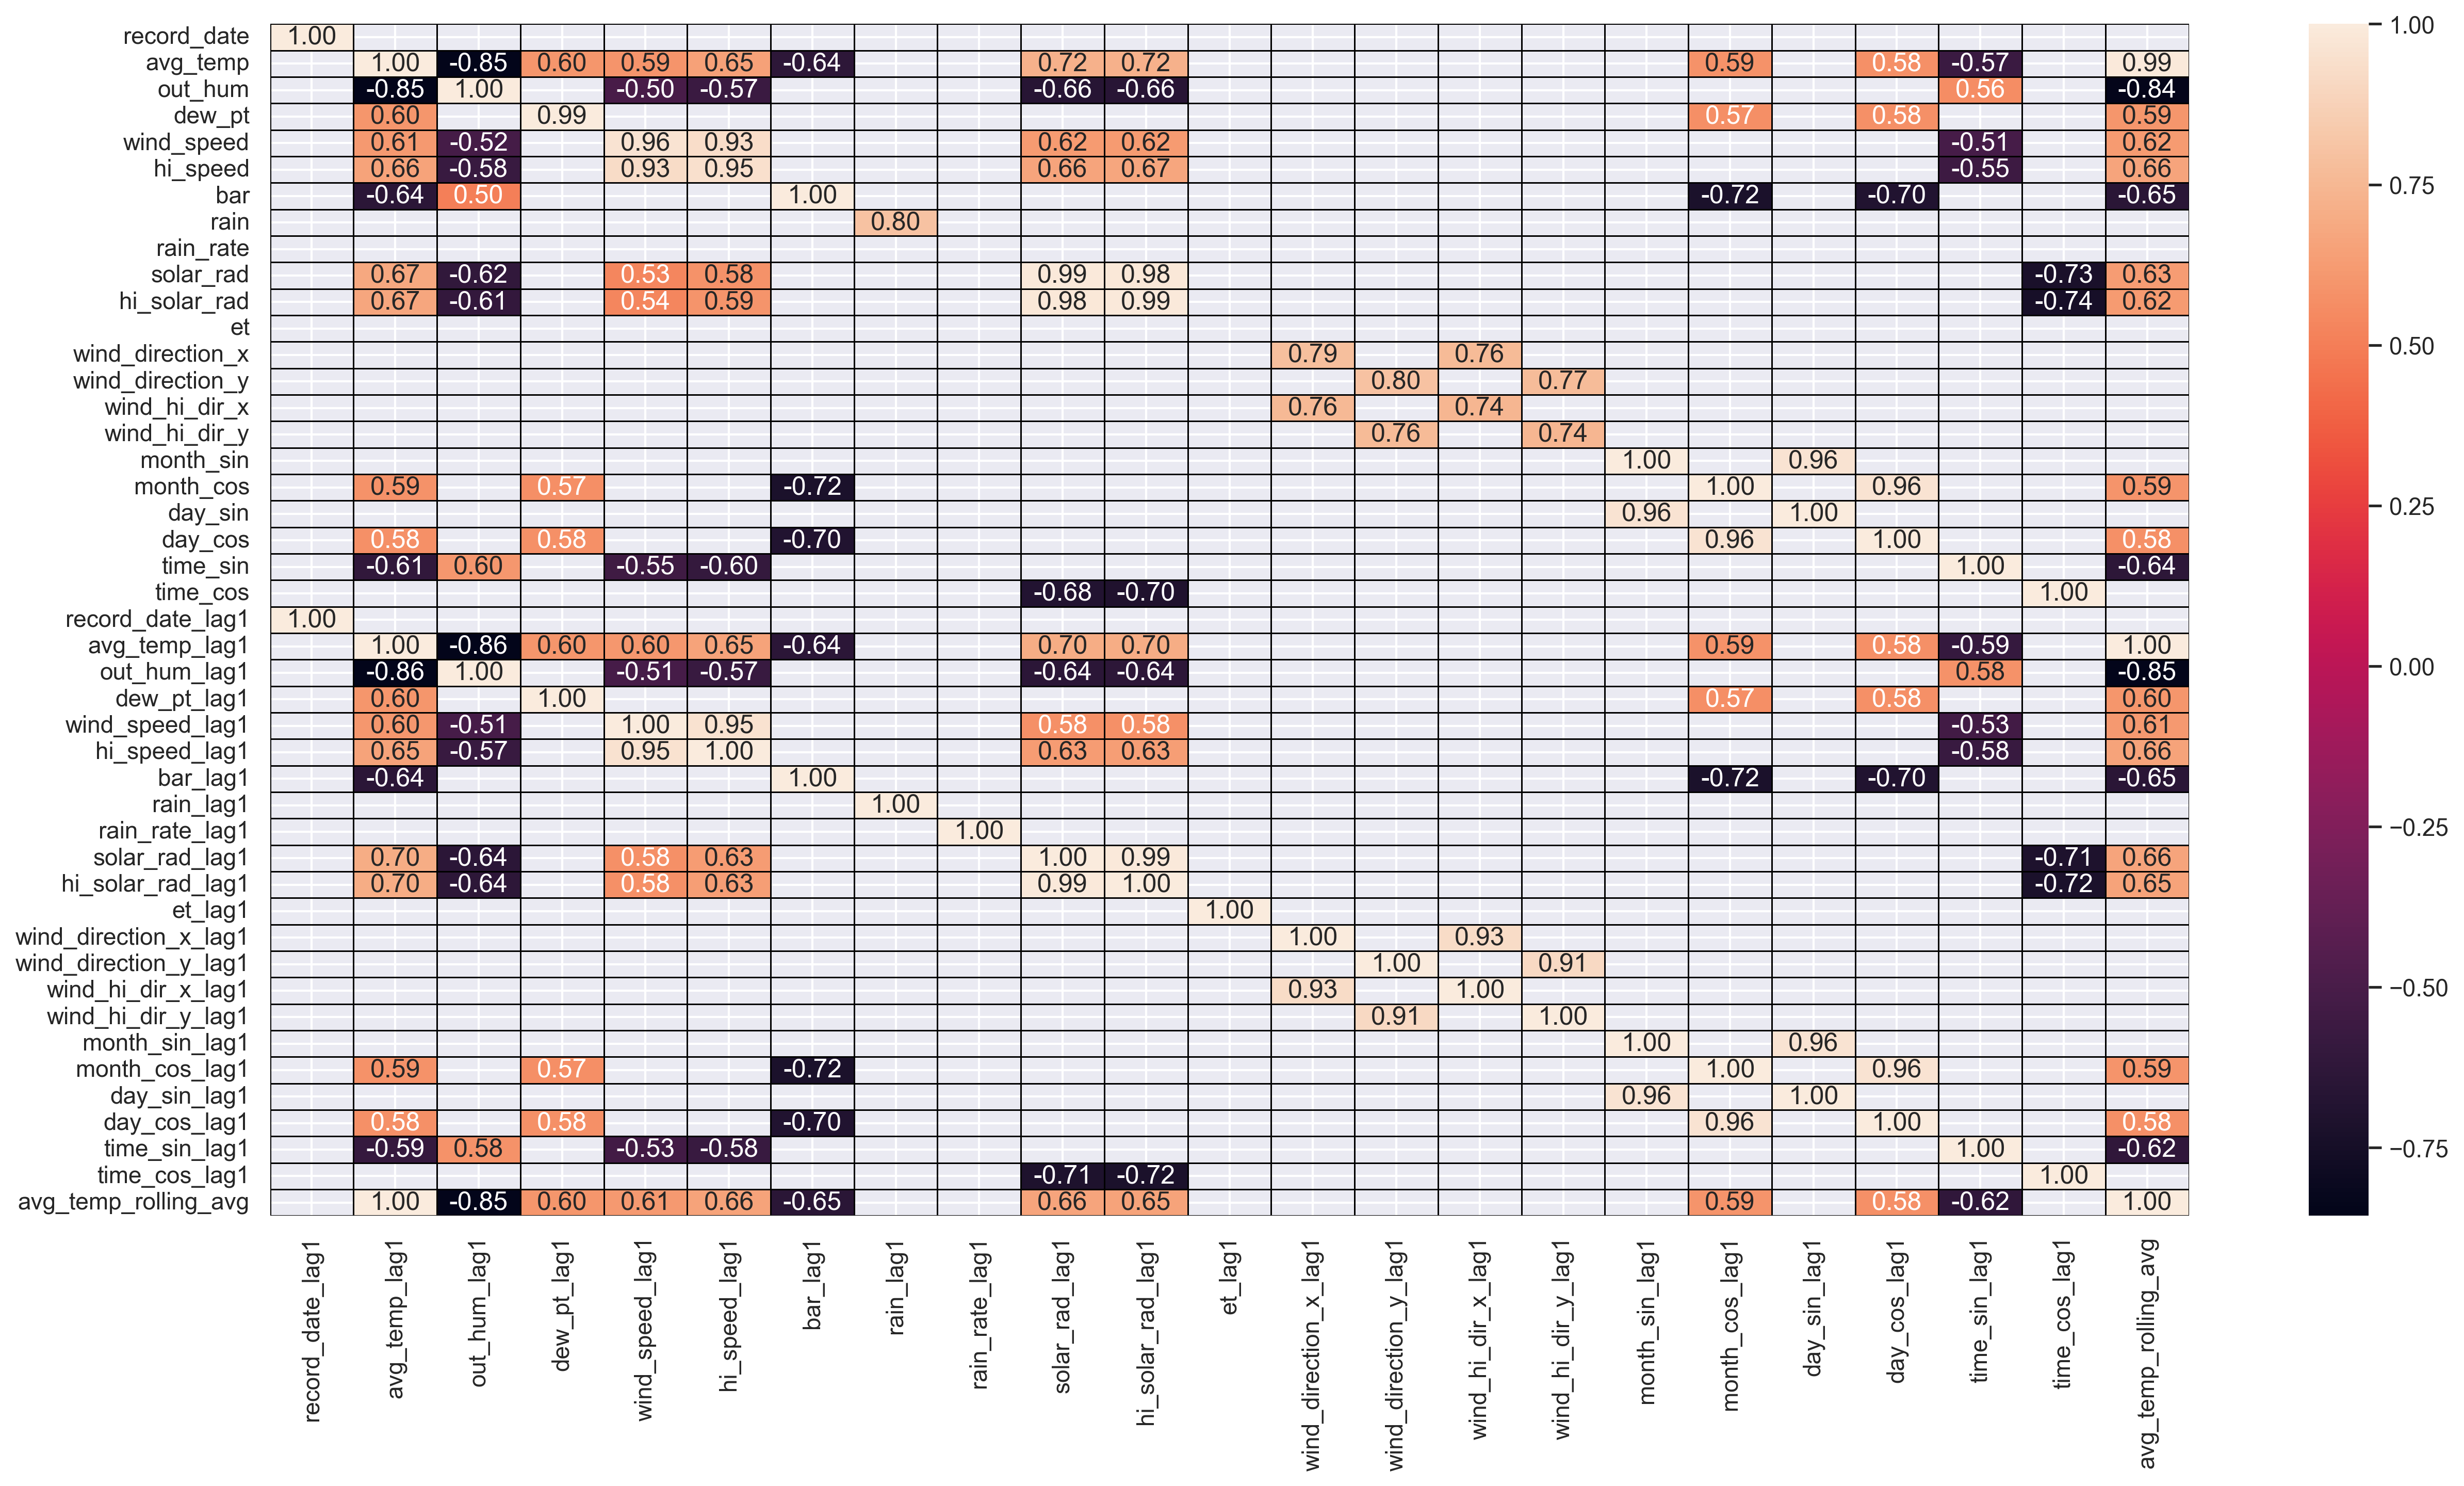

In [10]:
threshold = 0.5
mask = np.abs(corr_matrix) < threshold

plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidth=".25", linecolor="black", mask=mask)

# Linear Regression
Linear regression is a statistical technique used to find the relationship between a dependant variable and one or more independent variables. It predicts continuous values by fitting a straight line that best represents the data.

In this ML context, it finds the relationship between features and a label.

Algebraically, LR would be defined as it follows:

$y' = b + w_nx_n$

Where:
* $y'$ is the predicted label (dependant variable). In our case, the next average temperature.
* $b$ is the bias of the model.
* $w_n$ is the weight of the associated $n$ feature.
* $x_n$ is the value of the $n$ feature (independent variable).

## Training & Evaluation
To evaluate these models, we will use two metrics:

1. **Mean Absolute Error (MAE):** Average difference between predicted values and actual values in a dataset. Shows how far predictions are from the true values.
2. **R-Squared ($R^2$):** How well the data fit a regression line or curve. Ranging from 0 to 1, a higher value indicates a better fit.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Features & Target
features = ["avg_temp_lag1", "out_hum_lag1", "dew_pt_lag1", "wind_speed_lag1",
            "hi_speed_lag1", "bar_lag1", "solar_rad_lag1", "hi_solar_rad_lag1",
            "month_cos_lag1", "day_cos_lag1", "time_sin_lag1","avg_temp_rolling_avg"]
target = "avg_temp"
X = df[features]
y = df[target]

# Split
train_size = int(len(df)*0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Training
lr_model = LinearRegression()
lr_model.fit(X_train.values, y_train.values)

# Evaluation
predictions = lr_model.predict(X_test.values)
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"LR MAE: {mae:.4f} °C\nLR RMSE: {rmse:.4f} °C\nLR R2 Score: {r2:.4f}")

LR MAE: 0.2370 °C
LR RMSE: 0.3564 °C
LR R2 Score: 0.9982


## Feature Coefficients

In [12]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': np.round(lr_model.coef_,3)
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

                 Feature  Coefficient
0          avg_temp_lag1        1.507
8         month_cos_lag1        0.077
10         time_sin_lag1        0.002
1           out_hum_lag1        0.001
7      hi_solar_rad_lag1        0.001
3        wind_speed_lag1        0.001
6         solar_rad_lag1       -0.000
2            dew_pt_lag1       -0.001
4          hi_speed_lag1       -0.003
5               bar_lag1       -0.007
9           day_cos_lag1       -0.011
11  avg_temp_rolling_avg       -0.524


# Random Forest Regressor
This algorithm builds a "forest" of many individual decision trees (those map out choices and their potential outcomes) and combining their outputs into a single, more accurate result.

Some advantages over LR includes the **handling of non-linearity** (assumed in LR-based models), **more robustness to outliers** (in LR-based models, these may skew the regression line, whereas RFs partitions data into regions) and a **better handling of multicollinearity** (high correlation between features, which is done by randomly selecting a subset of features for each tree split).

## Training & Evaluation

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train.values, y_train.values)

rf_preds = rf_model.predict(X_test.values)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = root_mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest MAE: {rf_mae:.4f} °C")
print(f"Random Forest RMSE: {rf_rmse:.4f} °C")
print(f"Random Forest R2 Score: {rf_r2:.4f}")

Random Forest MAE: 0.2263 °C
Random Forest RMSE: 0.3292 °C
Random Forest R2 Score: 0.9985


## Feature Coefficients

                 Feature  Importance
0          avg_temp_lag1    0.996659
7      hi_solar_rad_lag1    0.000968
6         solar_rad_lag1    0.000823
11  avg_temp_rolling_avg    0.000706
10         time_sin_lag1    0.000641
4          hi_speed_lag1    0.000077
8         month_cos_lag1    0.000038
5               bar_lag1    0.000032
3        wind_speed_lag1    0.000024
9           day_cos_lag1    0.000019
1           out_hum_lag1    0.000011
2            dew_pt_lag1    0.000004


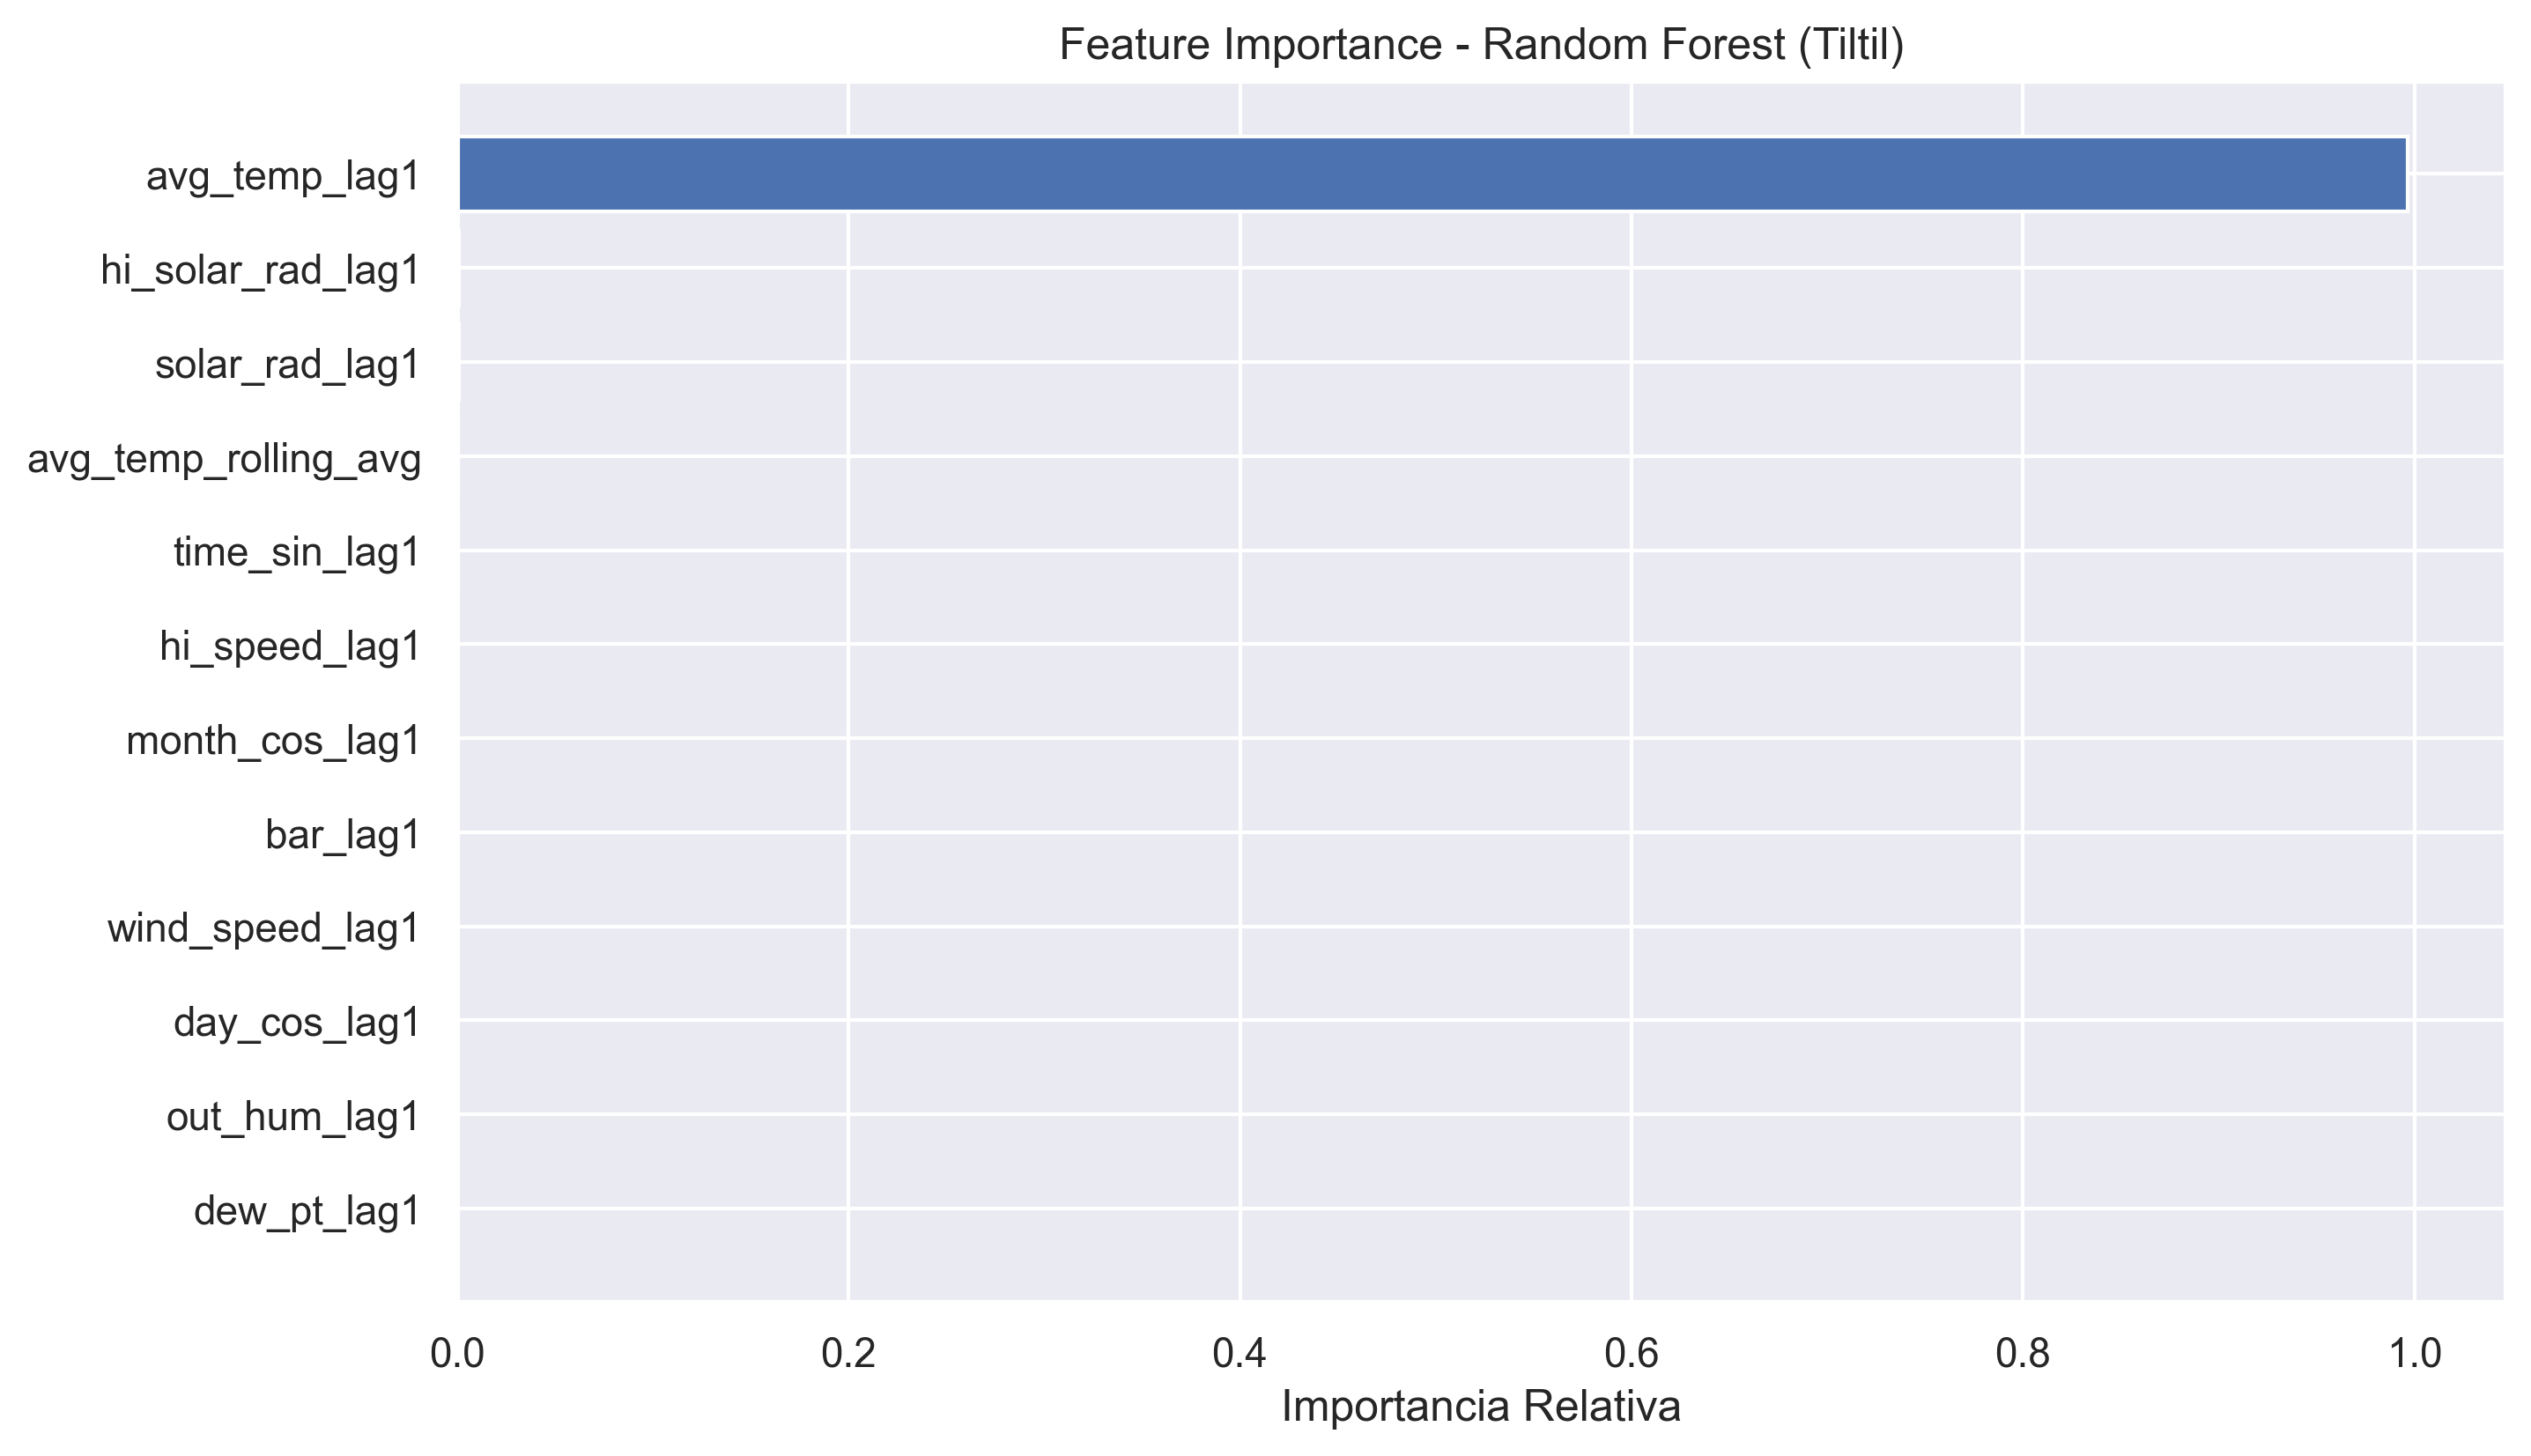

In [14]:
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importancia Relativa')
plt.title('Feature Importance - Random Forest (Tiltil)')
plt.gca().invert_yaxis()
plt.show()

# XGBoost
eXtreme Gradient Boosting (XGBoost) uses decision trees with gradient, a boosting algorithm that uses gradient descent (an algorithm that trains ML models through the minimization of errors between predicted and real results).

Decision trees tend to overfit, this ensemble methods may help to create more robusts models. Boosting combines multiple individual weak trees and form a strong learner: each weak learner is trained sequentially to correct the errors made by the previous models, later becoming strong learners.

In [15]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

xgb_model = xgb.XGBRegressor(
    n_estimators=10000,
    learning_rate=0.01,
    max_depth=5,
    n_jobs=-1,
    random_state=42,
    eval_metric="mae",
    early_stopping_rounds=500,
)

xgb_model.fit(
    X_train.values, y_train.values,
    eval_set=[(X_test.values, y_test)],
    verbose=False
)

xgb_preds = xgb_model.predict(X_test.values)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = root_mean_squared_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

print(f"XGBoost MAE: {xgb_mae:.4f} °C")
print(f"XGBoost RMSE: {xgb_rmse:.4f} °C")
print(f"XGBoost R2 Score: {xgb_r2:.4f}")

XGBoost MAE: 0.2117 °C
XGBoost RMSE: 0.3093 °C
XGBoost R2 Score: 0.9986


                 Feature  Importance
0          avg_temp_lag1    0.993127
7      hi_solar_rad_lag1    0.001861
6         solar_rad_lag1    0.001700
10         time_sin_lag1    0.001167
11  avg_temp_rolling_avg    0.000909
8         month_cos_lag1    0.000396
4          hi_speed_lag1    0.000261
3        wind_speed_lag1    0.000253
2            dew_pt_lag1    0.000110
5               bar_lag1    0.000083
1           out_hum_lag1    0.000073
9           day_cos_lag1    0.000059


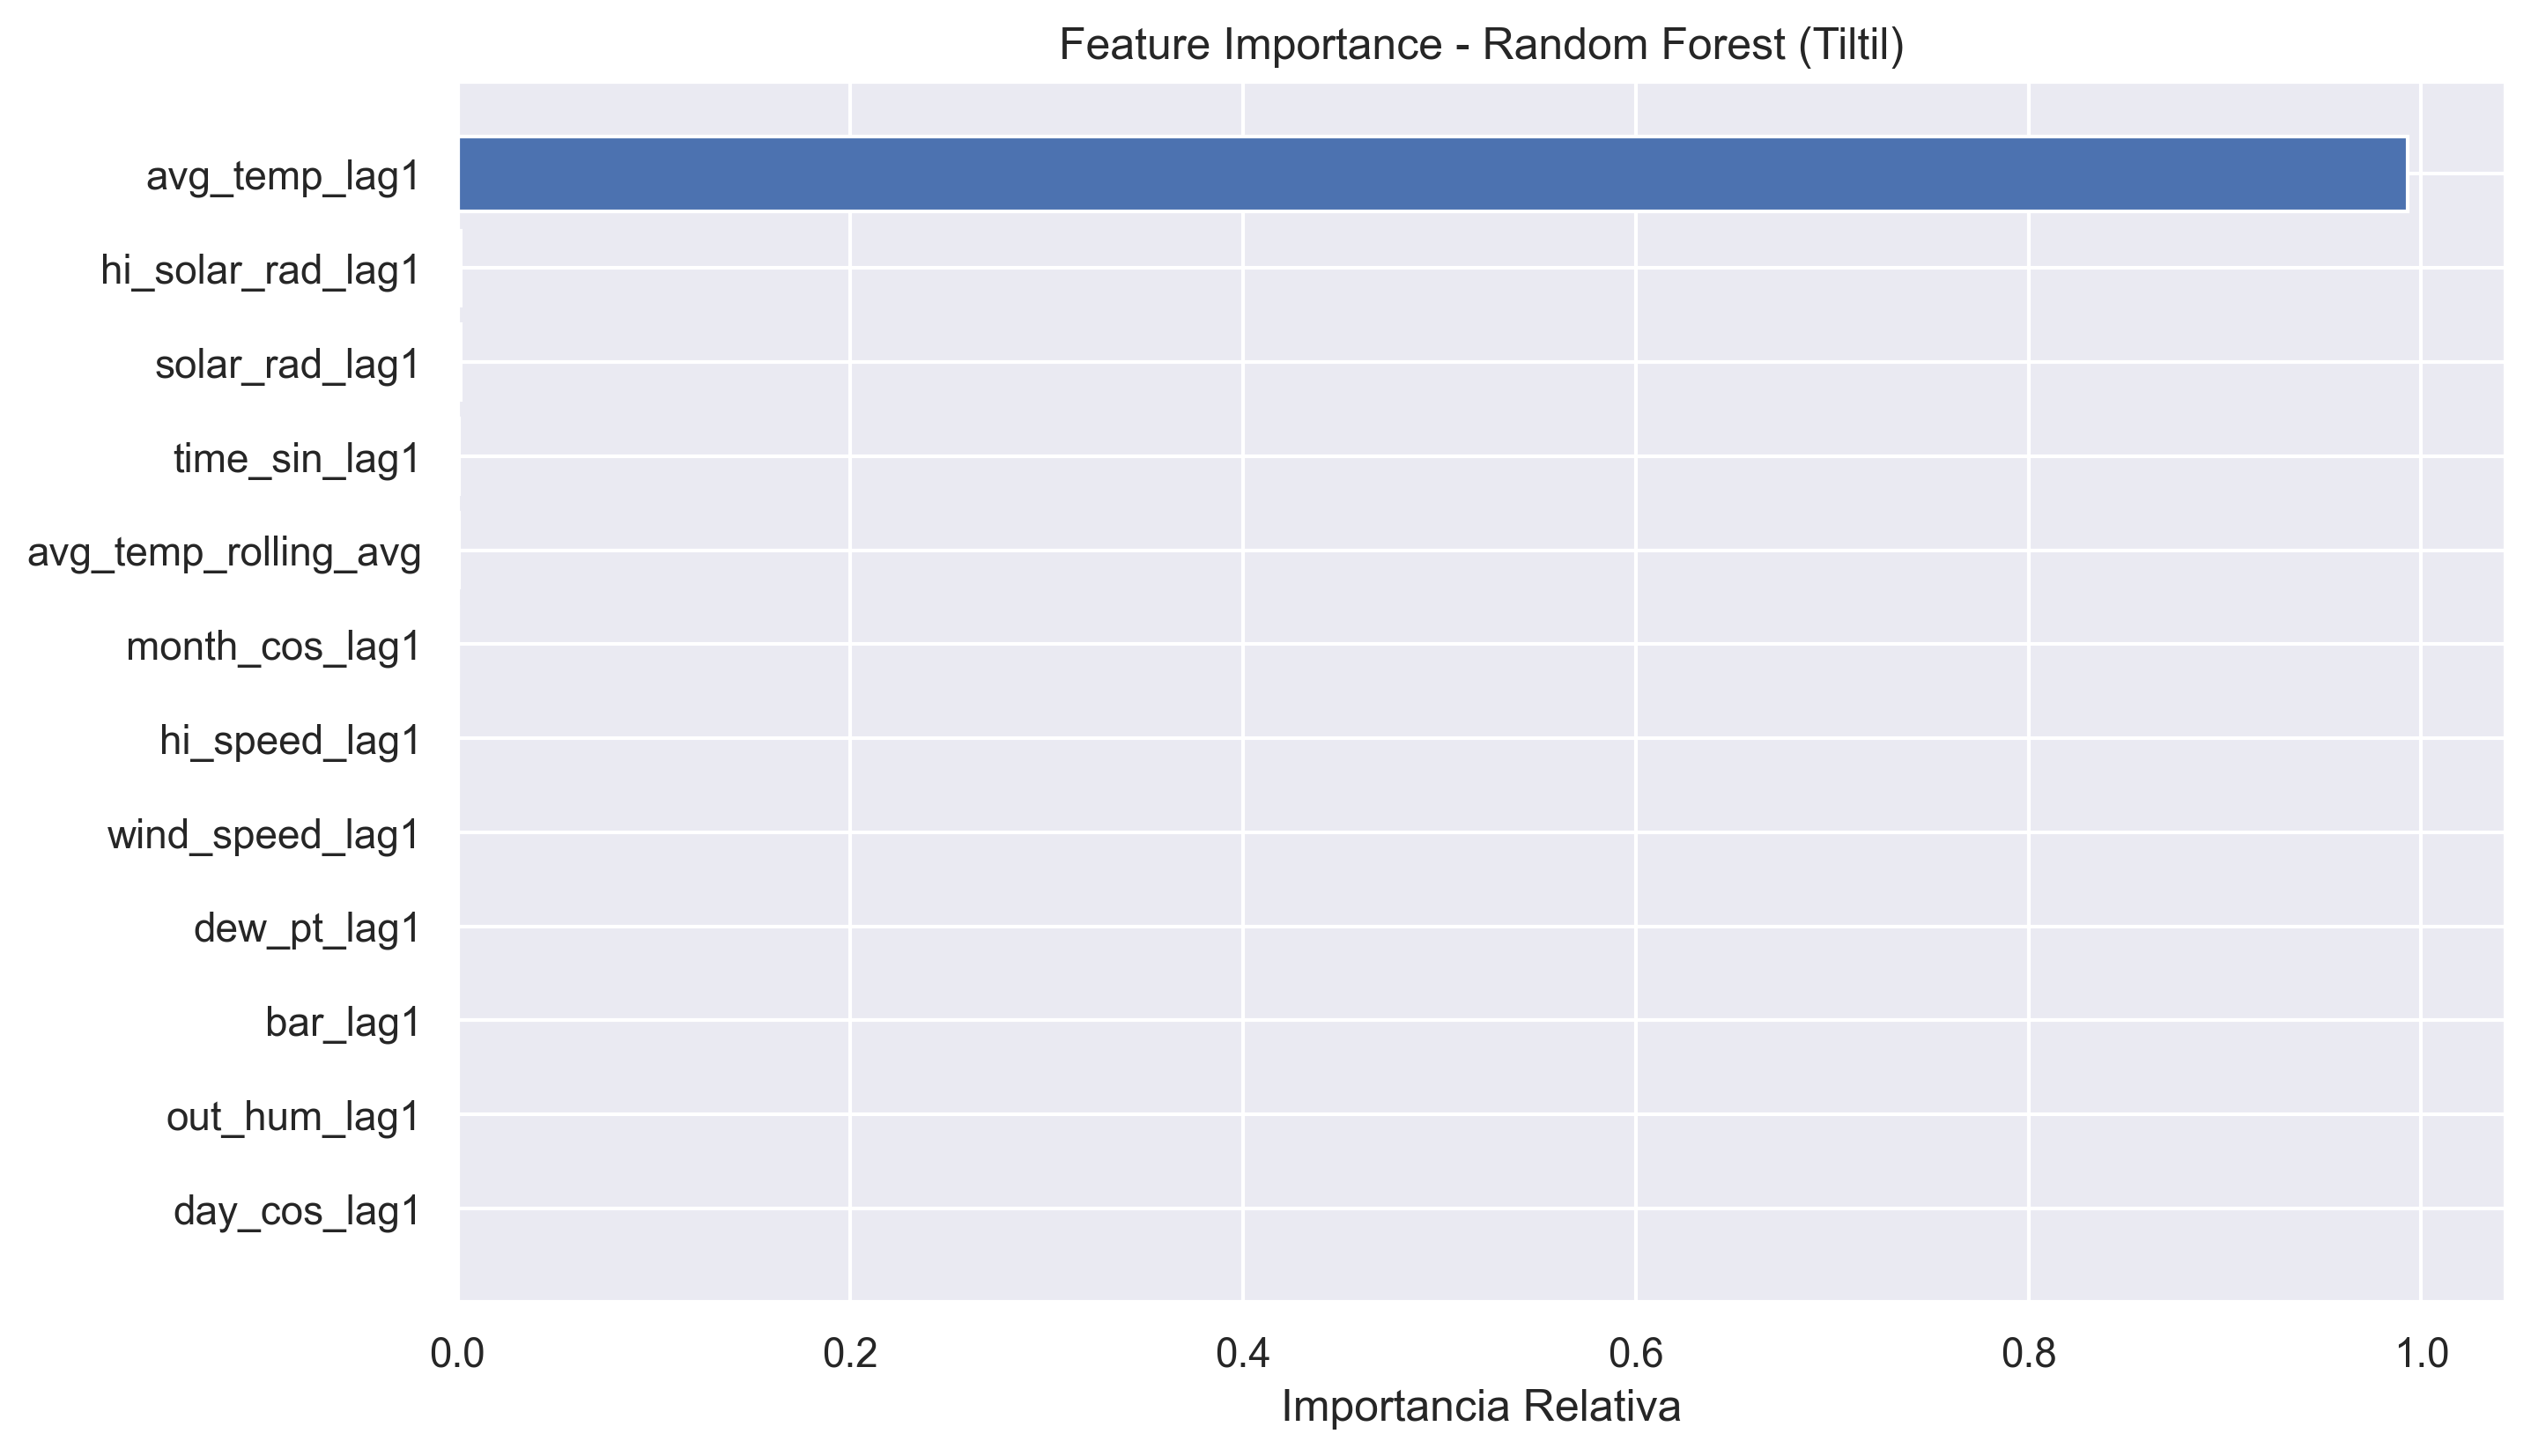

In [16]:
importances = xgb_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importancia Relativa')
plt.title('Feature Importance - Random Forest (Tiltil)')
plt.gca().invert_yaxis()
plt.show()

# Predictions

In [17]:
initial_num = -48

df_real_pred = df.iloc[:, [0,1]][initial_num:]
df_with_features = df.iloc[:, [23,24,25,26,27,28,31,32,39,41,42,44]][initial_num:]

df_with_features["next_temp_15min"] = np.round(rf_model.predict(df_with_features.values),5)
df_real_pred["avg_temp_pred_rf"] = df_with_features["next_temp_15min"].shift(1)
df_with_features.drop(columns="next_temp_15min", inplace=True)

df_with_features["next_temp_15min"] = np.round(lr_model.predict(df_with_features.values),5)
df_real_pred["avg_temp_pred_lr"] = df_with_features["next_temp_15min"].shift(1)
df_with_features.drop(columns="next_temp_15min", inplace=True)

df_with_features["next_temp_15min"] = np.round(xgb_model.predict(df_with_features.values),5)
df_real_pred["avg_temp_pred_xgb"] = df_with_features["next_temp_15min"].shift(1)
df_with_features.drop(columns="next_temp_15min", inplace=True)

df_real_pred.dropna(inplace=True)

display(df_real_pred)

,record_date,avg_temp,avg_temp_pred_rf,avg_temp_pred_lr,avg_temp_pred_xgb
634288,2026-05-18 08:00:00,-0.2,-0.15002,-0.28081,-0.333500
634289,2026-05-18 08:15:00,-0.1,-0.39318,-0.38528,-0.226340
634290,2026-05-18 08:30:00,2.0,-0.12427,-0.11893,0.135330
634291,2026-05-18 08:45:00,4.4,0.94513,0.12061,1.135060
634292,2026-05-18 09:00:00,6.3,3.34145,3.01621,3.772380
634293,2026-05-18 09:15:00,8.8,5.79579,6.03705,6.283820
634294,2026-05-18 09:30:00,10.1,7.84602,8.05140,8.157840
634295,2026-05-18 09:45:00,11.8,10.16654,10.67129,10.677070
634296,2026-05-18 10:00:00,13.2,11.43927,11.58101,11.747470
634297,2026-05-18 10:15:00,14.8,12.95849,13.17509,13.125150


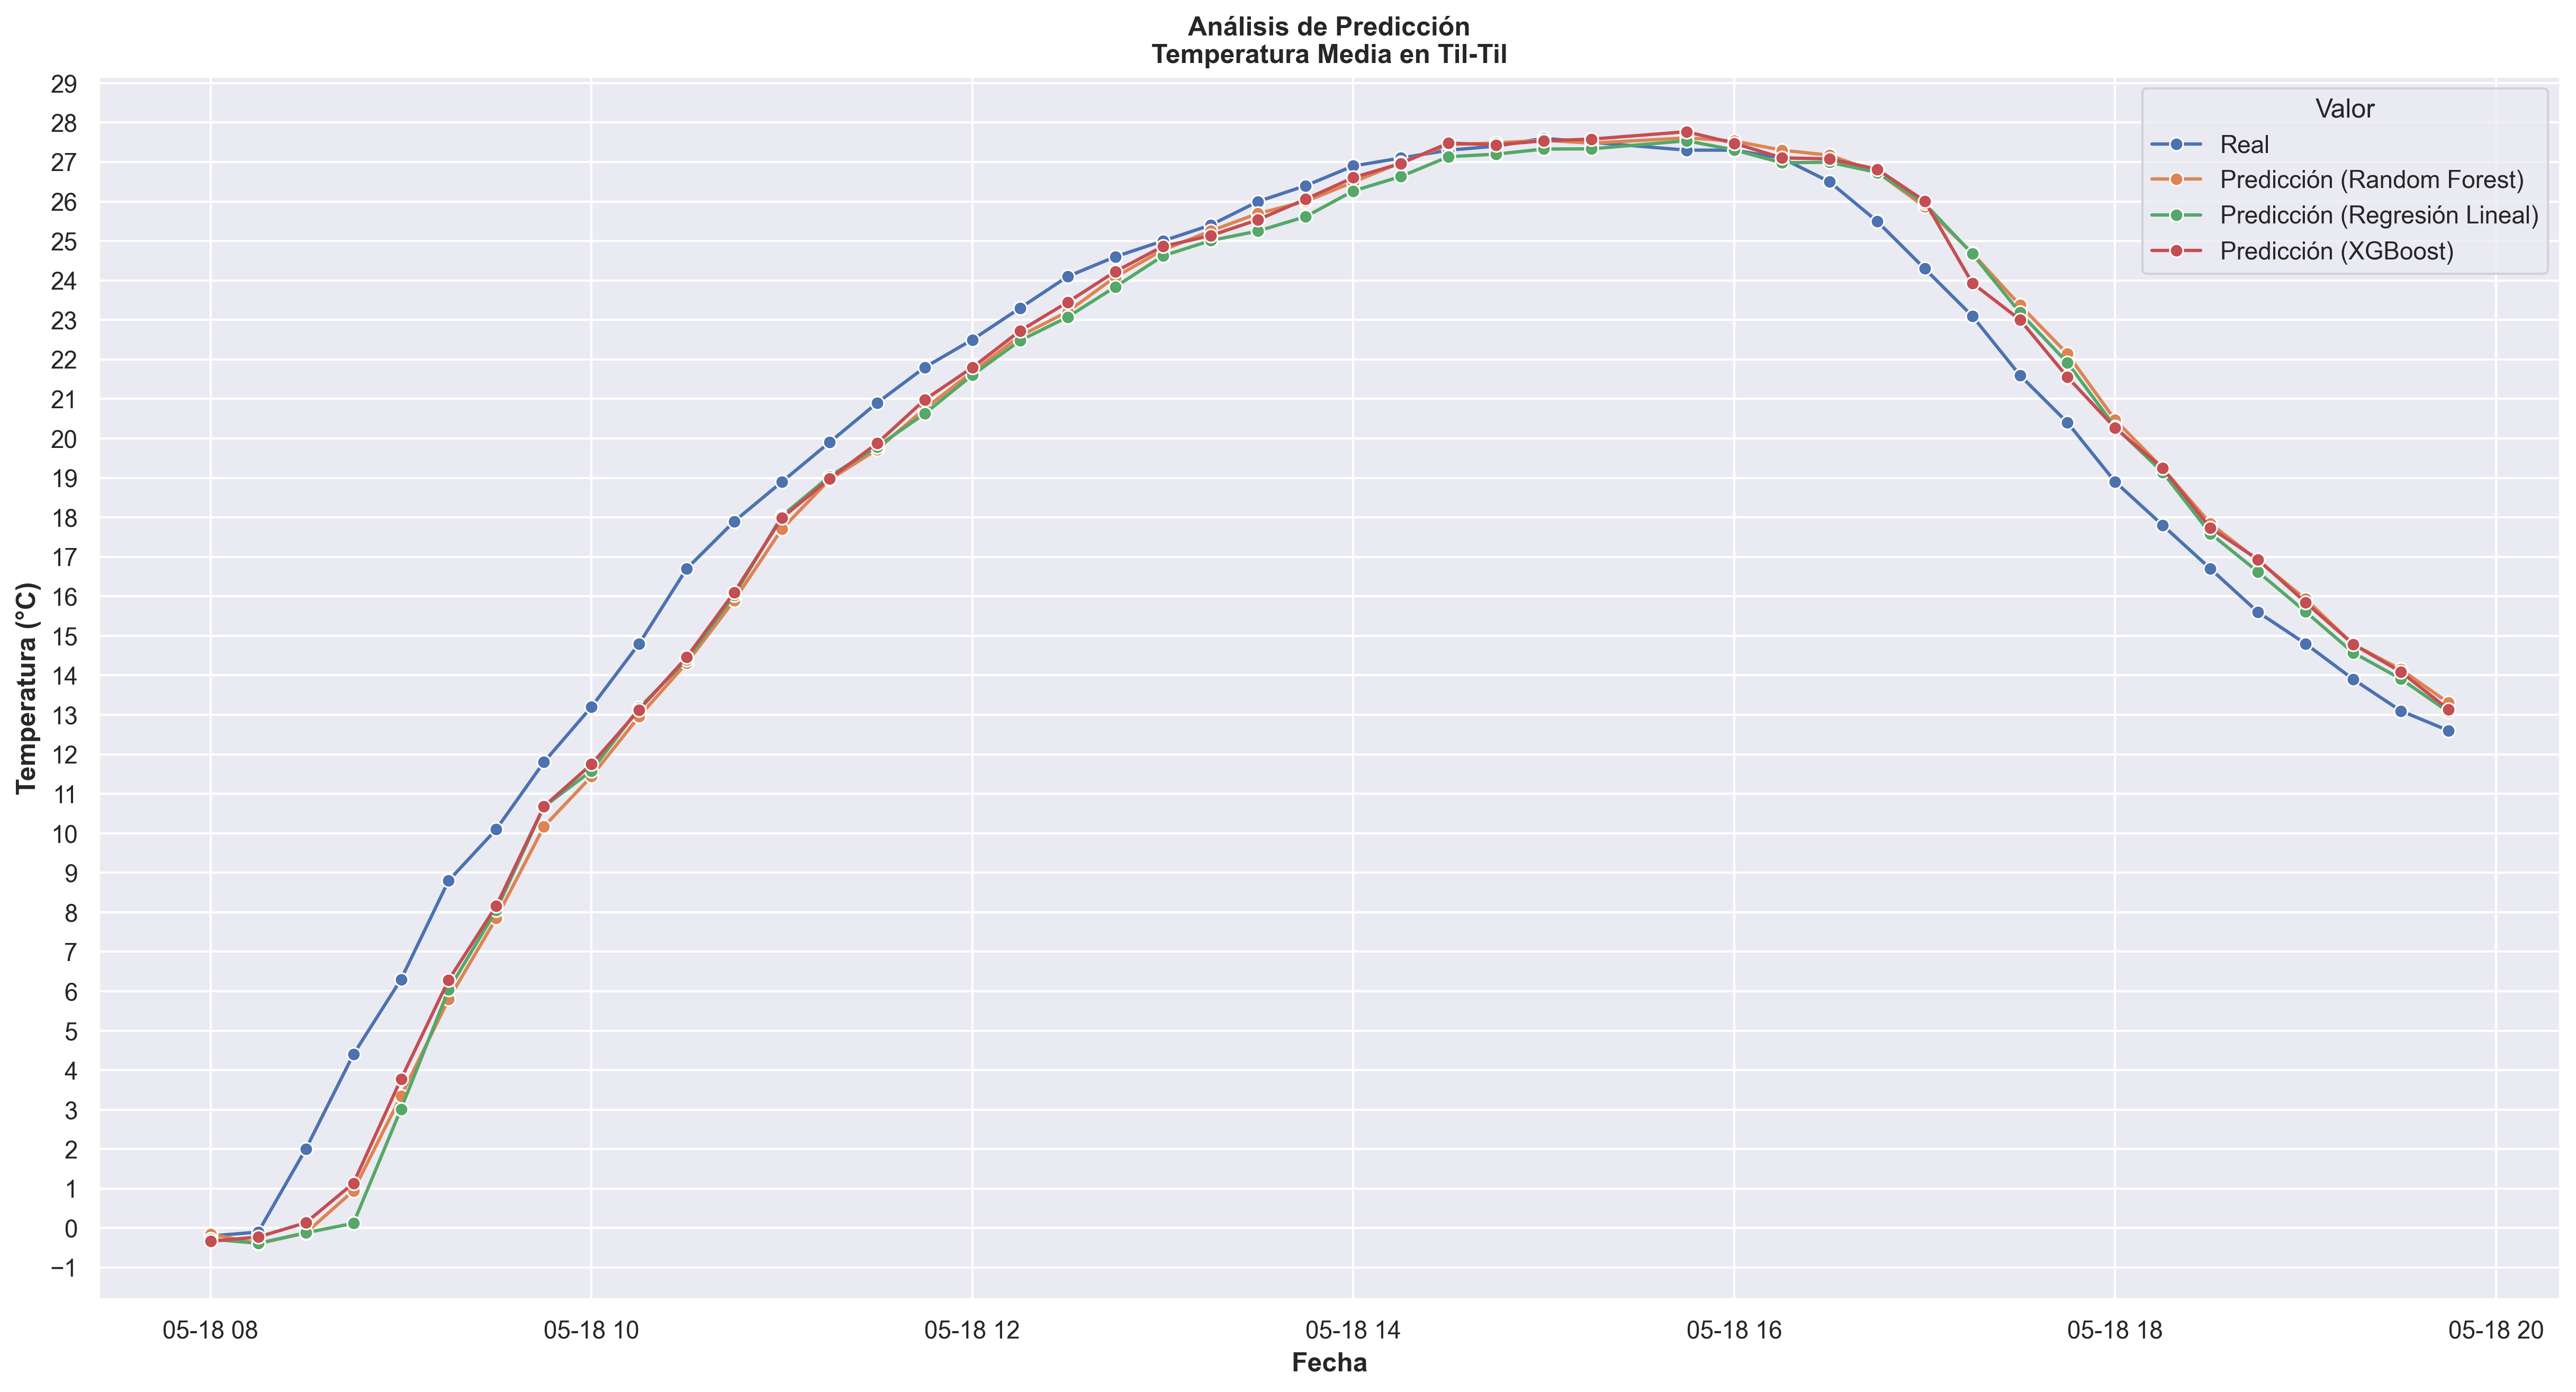

In [18]:
# Melting
df_plot = df_real_pred.melt(id_vars=['record_date'], 
                            value_vars=['avg_temp', 'avg_temp_pred_rf', 'avg_temp_pred_lr', 'avg_temp_pred_xgb'], 
                            var_name='Valor', 
                            value_name='Temperatura (°C)')

df_plot['Valor'] = df_plot['Valor'].map({
    'avg_temp': 'Real',
    'avg_temp_pred_rf': 'Predicción (Random Forest)',
    'avg_temp_pred_lr': 'Predicción (Regresión Lineal)',
    'avg_temp_pred_xgb': 'Predicción (XGBoost)'
})

plt.figure(figsize=(20, 10))

g = sns.lineplot(data=df_plot, x="record_date", y="Temperatura (°C)", hue="Valor", marker="o")
plt.yticks(np.arange(round(df_plot['Temperatura (°C)'].min()-1, 0), round(df_plot['Temperatura (°C)'].max()+2, 0), 1))

plt.title("Análisis de Predicción\nTemperatura Media en Til-Til", fontweight="bold")
plt.xlabel("Fecha", fontweight="bold")
plt.ylabel("Temperatura (°C)", fontweight="bold")
plt.show()

# Exporting models

In [19]:
import pickle

with open("./ml_models/modelo_tiltil_xgb.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
with open("./ml_models/modelo_tiltil_rf.pkl", "wb") as f:
    pickle.dump(rf_model, f)
with open("./ml_models/modelo_tiltil_lr.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# Summary
The following tables show the main results of the models evaluation.
## Without Rolling Avg
|       Model       |  MAE (°C)  |  RMSE (°C) |     $R^2$     | Size (Pickle) |
|:-----------------:|:----------:|:----------:|:----------:|:-------------:|
| Linear Regression |   0.3152   |    0.46    |    0.997   |   **~1 Kb**   |
|   Random Forest  |   0.2371   |   0.3404   |   0.9984   |     ~14 Mb    |
|      XGBoost      | **0.2206** | **0.3193** | **0.9986** |     ~25 Mb    |

* Linear Regression is the lightest model, using under a kilobyte in disk space, although it has the poorest metrics.
    * The forecasts are, on average, off by 0.3°C from the actual true values, with few larger errors or outliers making it able to reach 0.5°C.
* The XGBoost and Random Forest models are the winners of the comparison on every evaluation metric, but have a bigger size on disk (14x and 25x times more space).
    * $R^2$ is practically the same on both models.
    * Both MAE and RMSE have an approx. 0.02°C difference in favor of XGBoost.

## With Rolling Avg
|       Model       |  MAE (°C)  |  RMSE (°C) |     $R^2$     | Size (Pickle) |
|:-----------------:|:----------:|:----------:|:----------:|:-------------:|
| Linear Regression |   0.2370   |    0.3564    |    0.9982   |   **~1 Kb**   |
|   Random Forest  |   0.2263   |   0.3292   |   0.9985   |     ~14 Mb    |
|      XGBoost      | **0.2117** | **0.3093** | **0.9986** |     ~25 Mb    |

* The LR-based model presents a major improvement with this new feature (24.8% and 22.52% improvements on MAE & RMSE respectively), while maintaining its small size on disk.
    * New MAE and RMSE reaches almost same metrics obtained with the previous RF model.
* RF and XGBoost models did not show major improvements with this new feature (3-5% on MAE & RMSE metrics).